# Анализ лояльности пользователей Яндекс Афиши

# Введение

В рамках данного проекта проводится исследовательский анализ данных сервиса «Яндекс Афиша», направленный на изучение пользовательского поведения и факторов, влияющих на повторные визиты и совершение покупок на платформе. Основная задача работы — понять, какие характеристики и действия пользователей связаны с более высокой лояльностью и возвратом к сервису.

Для команды маркетинга подобный анализ представляет практическую ценность, так как позволяет выявить группы пользователей, наиболее склонных к повторному использованию сервиса. Полученные результаты могут быть использованы для более точной настройки маркетинговых кампаний, развития персонализированных предложений, более эффективного распределения рекламных бюджетов, а также для повышения общего уровня удержания клиентов.

В основе исследования лежат данные о заказах билетов, мероприятиях и характеристиках пользователей, полученные из базы данных с использованием SQL-запросов. Набор данных содержит информацию о времени и параметрах заказов, типах мероприятий, используемых устройствах, выручке и частоте покупок, что позволяет провести комплексный анализ поведения пользователей и их вовлечённости в сервис.

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [1]:
!pip install sqlalchemy
!pip install psycopg2-binary
!pip install phik
!pip install python-dotenv
!pip -q install python-dotenv

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
  Using cached phik-0.12.5-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.6 kB)
  Using cached scipy-1.17.0-cp312-cp312-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached matplotlib-3.10.8-cp312-cp312-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached contourpy-1.3.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp312-cp312-macosx_10_13_universal2.whl.metadata (114 kB)
  Using cached kiwisolver-1.4.9-cp312-cp312-macosx_11_0_arm64.whl.metadata (6.3 kB)
Using cached phik-0.12.5-cp312-cp312-macosx_11_0_arm64.whl (665 kB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached matplot

In [2]:
# --- Standard library ---
import os
import warnings

# --- Third-party ---
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from dotenv import load_dotenv
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

from phik import phik_matrix

from scipy.stats import spearmanr

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

# 1) Явно грузим .env из текущей папки ноутбука
load_dotenv(".env", override=True)

# 2) Быстрая проверка, что переменные реально подхватились
for k in ["DB_HOST", "DB_PORT", "DB_NAME", "DB_USER", "DB_PASSWORD"]:
    v = os.getenv(k)
    print(k, "=", None if v is None else (v if k != "DB_PASSWORD" else f"len={len(v)}"))

# 3) Создаем подключение
url = URL.create(
    "postgresql+psycopg2",
    username=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    host=os.getenv("DB_HOST"),
    port=int(os.getenv("DB_PORT")),
    database=os.getenv("DB_NAME"),
    query={"sslmode": "require"},
)
engine = create_engine(url)

# 4) Тест
pd.read_sql("SELECT 1 AS test", con=engine)

ModuleNotFoundError: No module named 'numpy'

In [ ]:
pd.read_sql("SELECT 1 as test", engine)

,test
0,1


In [ ]:
 query = '''
SELECT 
    p.order_id,
    p.user_id,
    p.created_dt_msk,
    p.created_ts_msk,
    p.event_id,
    p.cinema_circuit,
    p.age_limit,
    p.currency_code,
    p.device_type_canonical,
    p.revenue,
    p.service_name,
    p.tickets_count,
    p.total,
    (p.created_dt_msk::DATE - LAG(p.created_dt_msk::DATE) OVER (
        PARTITION BY p.user_id 
        ORDER BY p.created_dt_msk::DATE, p.order_id
    )) AS days_since_prev
FROM afisha.purchases AS p
JOIN afisha.events AS e ON p.event_id = e.event_id
WHERE 
    p.device_type_canonical IN ('mobile', 'desktop')
    AND e.event_type_main != 'фильм'
ORDER BY p.user_id, p.created_dt_msk, p.order_id;
'''

---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [ ]:
df = pd.read_sql_query(query, con=engine)
df.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   order_id               290611 non-null  int64         
 1   user_id                290611 non-null  object        
 2   created_dt_msk         290611 non-null  datetime64[ns]
 3   created_ts_msk         290611 non-null  datetime64[ns]
 4   event_id               290611 non-null  int64         
 5   cinema_circuit         290611 non-null  object        
 6   age_limit              290611 non-null  int64         
 7   currency_code          290611 non-null  object        
 8   device_type_canonical  290611 non-null  object        
 9   revenue                290611 non-null  float64       
 10  service_name           290611 non-null  object        
 11  tickets_count          290611 non-null  int64         
 12  total                  290611 non-null  floa

In [ ]:
df.describe()

,order_id,event_id,age_limit,revenue,tickets_count,total,days_since_prev
count,2.906110e+05,290611.000000,290611.000000,290611.000000,290611.000000,290611.000000,268678.000000
mean,4.326225e+06,438019.834992,10.207267,625.584360,2.754311,7532.524374,3.222381
std,2.497551e+06,147423.078841,6.518540,1227.693064,1.170620,15333.076041,11.350509
min,1.000000e+00,4436.000000,0.000000,-90.760000,1.000000,-358.850000,0.000000
25%,2.163618e+06,361772.000000,6.000000,116.850000,2.000000,2160.070000,0.000000
50%,4.326366e+06,498275.000000,12.000000,356.010000,3.000000,4775.020000,0.000000
75%,6.488330e+06,546287.000000,16.000000,810.130000,4.000000,8955.950000,1.000000
max,8.653108e+06,592325.000000,18.000000,81174.540000,57.000000,811745.400000,148.000000


> Промежуточный вывод: загрузка данных и первичная проверка качества

На первом этапе выполнено подключение к базе данных `data-analyst-afisha` и выгрузка выборки заказов пользователей с использованием SQL-запроса. В датафрейм вошли данные о заказах, пользователях, событиях и сервисах, а также рассчитанный признак `days_since_prev` — количество дней с предыдущей покупки пользователя.

Полученный датафрейм содержит `290 611` строк и `14 столбцов`. Типы данных в целом заданы корректно: даты и время приведены к формату `datetime`, числовые показатели (выручка, количество билетов, сумма заказа, интервал между покупками) имеют числовые типы, категориальные признаки представлены строками. В столбце `days_since_prev` присутствуют пропуски, что логично для первых покупок пользователей.

Анализ базовых статистик показал, что распределения финансовых метрик неоднородны:
средняя выручка составляет около `626 руб`., при этом наблюдается высокая вариативность значений и наличие выбросов. В данных присутствуют отрицательные значения выручки и суммы заказа, а также очень большие значения, что может указывать на возвраты, корректировки или аномальные записи и требует отдельной проверки. Количество билетов в заказе варьируется в широком диапазоне, что также подтверждает наличие редких экстремальных значений. Интервал между покупками распределён неравномерно: `медиана равна 0`, что говорит о возможных повторных заказах в тот же день.

Итог: данные успешно загружены и в целом имеют корректную структуру, однако в них присутствуют пропуски в `days_since_prev`, отрицательные и экстремальные значения финансовых показателей, а также выбросы в количестве билетов. Эти особенности необходимо учесть на этапе предобработки перед дальнейшим анализом.

---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


> Шаг 1. Загружаем курс и проверяем его качество

In [ ]:
rate_url = "https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv"
rate_df = pd.read_csv(rate_url)

rate_df['data'] = pd.to_datetime(rate_df['data'], errors='coerce')
rate_df['data_date'] = rate_df['data'].dt.date

# 1) Проверка пропусков
print("Пропуски в курсах:")
display(rate_df[['data', 'data_date', 'nominal', 'curs', 'cdx']].isna().sum())

# 2) Проверка дублей дат
dup_cnt = rate_df['data_date'].duplicated().sum()
print("Дубли по дате:", dup_cnt)

# 3) Быстрая адекватность значений
display(rate_df[['nominal','curs']].describe())
display(rate_df['cdx'].value_counts())


Пропуски в курсах:


data         0
data_date    0
nominal      0
curs         0
cdx          0
dtype: int64

Дубли по дате: 0


,nominal,curs
count,357.0,357.000000
mean,100.0,19.755818
std,0.0,0.833798
min,100.0,17.848600
25%,100.0,19.120200
50%,100.0,19.876000
75%,100.0,20.443300
max,100.0,21.937100


kzt    357
Name: cdx, dtype: int64

> Шаг 2. Нормализуем валюту и готовим дату заказа

In [ ]:
# на всякий случай приводим валюту к нижнему регистру
df['currency_code'] = df['currency_code'].astype(str).str.lower()

# дата заказа без времени
df['order_date'] = pd.to_datetime(df['created_dt_msk'], errors='coerce').dt.date

# посмотрим валюты
df['currency_code'].value_counts()


rub    285542
kzt      5069
Name: currency_code, dtype: int64

> Шаг 3. Джойним курс к заказам по дате

In [ ]:
for col in ['data_date', 'curs', 'nominal', 'cdx']:
    if col in df.columns:
        df = df.drop(columns=col)

df = df.merge(
    rate_df[['data_date', 'curs', 'nominal', 'cdx']],
    left_on='order_date',
    right_on='data_date',
    how='left'
)

> Шаг 4. Проверяем, что курс подтянулся для KZT

In [ ]:
kzt_rate_na = df.loc[df['currency_code'].eq('kzt'), 'curs'].isna().mean()
print("Доля пропусков курса среди KZT заказов:", kzt_rate_na)


Доля пропусков курса среди KZT заказов: 0.0


> Шаг 5. Считаем revenue_rub правильно

In [ ]:
df['revenue_rub'] = df['revenue']  # по умолчанию рубли оставляем как есть

mask_kzt = df['currency_code'].eq('kzt')
df.loc[mask_kzt, 'revenue_rub'] = (
    df.loc[mask_kzt, 'revenue'] * df.loc[mask_kzt, 'curs'] / df.loc[mask_kzt, 'nominal']
)

In [ ]:
df[['currency_code','revenue','curs','nominal','revenue_rub','order_date']].head(10)

,currency_code,revenue,curs,nominal,revenue_rub,order_date
0,rub,1521.94,18.6972,100,1521.94,2024-08-20
1,rub,289.45,18.3419,100,289.45,2024-07-23
2,rub,1258.57,19.6475,100,1258.57,2024-10-06
3,rub,8.49,18.5010,100,8.49,2024-07-13
4,rub,1390.41,19.6648,100,1390.41,2024-10-04
5,rub,902.74,20.0531,100,902.74,2024-10-23
6,rub,917.83,18.7730,100,917.83,2024-08-15
7,rub,47.78,19.3741,100,47.78,2024-09-29
8,rub,74.84,19.7185,100,74.84,2024-10-15
9,rub,1421.91,18.0419,100,1421.91,2024-06-20


---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

In [ ]:
df.isna().sum().sort_values(ascending=False)

days_since_prev          21933
order_id                     0
user_id                      0
cdx                          0
nominal                      0
curs                         0
data_date                    0
order_date                   0
total                        0
tickets_count                0
service_name                 0
revenue                      0
device_type_canonical        0
currency_code                0
age_limit                    0
cinema_circuit               0
event_id                     0
created_ts_msk               0
created_dt_msk               0
revenue_rub                  0
dtype: int64

In [ ]:
df.dtypes

order_id                          int64
user_id                          object
created_dt_msk           datetime64[ns]
created_ts_msk           datetime64[ns]
event_id                          int64
cinema_circuit                   object
age_limit                         int64
currency_code                    object
device_type_canonical            object
revenue                         float64
service_name                     object
tickets_count                     int64
total                           float64
days_since_prev                 float64
order_date                       object
data_date                        object
curs                            float64
nominal                           int64
cdx                              object
revenue_rub                     float64
dtype: object

In [ ]:
# Проверяем пропуски: после выгрузки/джойна они должны быть только в days_since_prev
na_cnt = df.isna().sum().sort_values(ascending=False)
display(na_cnt[na_cnt > 0])

print("Столбцы с пропусками:", list(na_cnt[na_cnt > 0].index))


days_since_prev    21933
dtype: int64

Столбцы с пропусками: ['days_since_prev']


In [ ]:
# user_id оставляем строкой, чтобы не потерять пользователей (в id есть буквы)
df['user_id'] = df['user_id'].astype('string').str.strip()

print("Уникальных пользователей:", df['user_id'].nunique())
print("Пример user_id:", df['user_id'].dropna().head(5).tolist())


Уникальных пользователей: 21933
Пример user_id: ['0002849b70a3ce2', '0005ca5e93f2cf4', '0005ca5e93f2cf4', '000898990054619', '000898990054619']


In [ ]:
# Проверяем полные и неполные (системные) дубликаты
full_dups = df.duplicated().sum()

dup_cols = [c for c in df.columns if c not in ['order_id', 'days_since_prev']]
partial_dups = df.duplicated(subset=dup_cols).sum()

print("Полные дубликаты:", full_dups)
print("Неполные (без order_id и days_since_prev):", partial_dups)
print("Доля неполных:", round(partial_dups / len(df) * 100, 4), "%")


Полные дубликаты: 0
Неполные (без order_id и days_since_prev): 40
Доля неполных: 0.0138 %


In [ ]:
# Удаляем неполные дубликаты
rows_before = len(df)

df = df.drop_duplicates(subset=dup_cols, keep='first').copy()

rows_after = len(df)
print("Строк было:", rows_before)
print("Строк стало:", rows_after)
print("Удалено:", rows_before - rows_after, "(", round((rows_before-rows_after)/rows_before*100, 4), "% )")


Строк было: 290611
Строк стало: 290571
Удалено: 40 ( 0.0138 % )


In [ ]:
# Пересчитываем days_since_prev, чтобы признак соответствовал очищенным данным
df = df.sort_values(['user_id', 'created_ts_msk']).copy()
df['days_since_prev'] = df.groupby('user_id')['created_dt_msk'].diff().dt.days

# Контроль: пропуски должны быть только у первых заказов
print("Пропусков в days_since_prev:", df['days_since_prev'].isna().sum())


Пропусков в days_since_prev: 21933


In [ ]:
df = df.sort_values(['user_id', 'created_ts_msk']).copy()
df['days_since_prev'] = df.groupby('user_id')['created_dt_msk'].diff().dt.days

In [ ]:
# Быстрая проверка ключевых метрик
display(df[['revenue_rub', 'tickets_count', 'days_since_prev']].describe())

print("revenue_rub <= 0:", (df['revenue_rub'] <= 0).sum(), "(", round((df['revenue_rub'] <= 0).mean()*100, 2), "% )")
print("tickets_count <= 0:", (df['tickets_count'] <= 0).sum())
print("days_since_prev < 0:", (df['days_since_prev'] < 0).sum())


,revenue_rub,tickets_count,days_since_prev
count,290571.000000,290571.000000,268638.000000
mean,555.585977,2.754318,3.222861
std,875.528775,1.170600,11.351286
min,-90.760000,1.000000,0.000000
25%,113.970000,2.000000,0.000000
50%,351.140000,3.000000,0.000000
75%,802.050000,4.000000,1.000000
max,81174.540000,57.000000,148.000000


revenue_rub <= 0: 5906 ( 2.03 % )
tickets_count <= 0: 0
days_since_prev < 0: 0


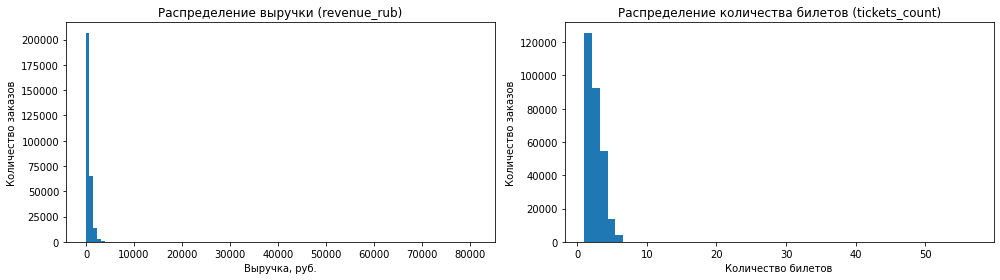

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Гистограмма выручки
axes[0].hist(df['revenue_rub'], bins=100)
axes[0].set_title('Распределение выручки (revenue_rub)')
axes[0].set_xlabel('Выручка, руб.')
axes[0].set_ylabel('Количество заказов')

# Гистограмма количества билетов
axes[1].hist(df['tickets_count'], bins=50)
axes[1].set_title('Распределение количества билетов (tickets_count)')
axes[1].set_xlabel('Количество билетов')
axes[1].set_ylabel('Количество заказов')

plt.tight_layout()
plt.show()


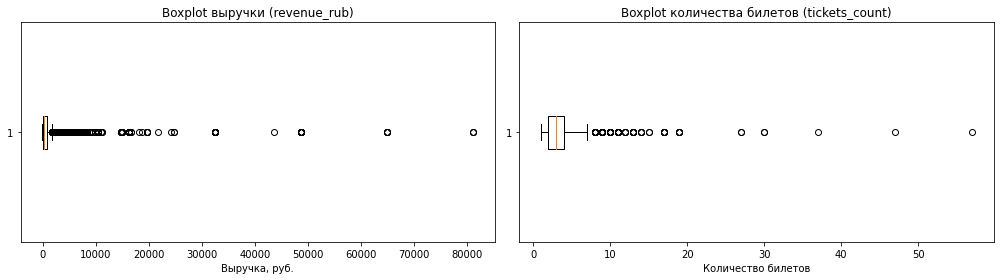

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Boxplot выручки
axes[0].boxplot(df['revenue_rub'], vert=False)
axes[0].set_title('Boxplot выручки (revenue_rub)')
axes[0].set_xlabel('Выручка, руб.')

# Boxplot количества билетов
axes[1].boxplot(df['tickets_count'], vert=False)
axes[1].set_title('Boxplot количества билетов (tickets_count)')
axes[1].set_xlabel('Количество билетов')

plt.tight_layout()
plt.show()

> Анализ распределений `revenue_rub` и `tickets_count`

Для оценки распределений ключевых числовых показателей были использованы гистограммы и диаграммы размаха (boxplot).

**Выручка с заказа (`revenue_rub`)**

- Распределение имеет выраженную правостороннюю асимметрию с длинным «хвостом».
- Наблюдаются экстремальные значения, существенно превышающие основную массу заказов.
- Такие выбросы способны значительно искажать агрегированные метрики (средние значения, суммарную выручку и т.д.).
- В связи с этим для дальнейшего анализа требуется фильтрация выбросов по `revenue_rub`.

**Количество билетов в заказе (`tickets_count`)**

- Распределение сконцентрировано вокруг небольших значений (в основном 1–4 билета).
- Редкие большие значения присутствуют, но выглядят логичными и не свидетельствуют об ошибках данных.
- Признак не содержит аномалий, требующих дополнительной фильтрации.

**Вывод**

Фильтрация выбросов будет применяться только к показателю **`revenue_rub`**, тогда как значения **`tickets_count`** сохраняются без изменений, поскольку они выглядят корректными и отражают реальное пользовательское поведение.


In [ ]:
# Исключаем нулевую/отрицательную выручку (возвраты/корректировки не являются валидными покупками)
rows_before = len(df)

df = df[df['revenue_rub'] > 0].copy()

rows_after = len(df)
print("Удалено строк (revenue_rub <= 0):", rows_before - rows_after, "(", round((rows_before-rows_after)/rows_before*100, 2), "% )")


Удалено строк (revenue_rub <= 0): 5906 ( 2.03 % )


In [ ]:
# Фильтруем выбросы по 99 перцентилю revenue_rub
p99 = df['revenue_rub'].quantile(0.99)

rows_before = len(df)
df = df[df['revenue_rub'] <= p99].copy()
rows_after = len(df)

print("p99 revenue_rub =", round(p99, 2))
print("Удалено строк (выбросы > p99):", rows_before - rows_after, "(", round((rows_before-rows_after)/rows_before*100, 2), "% )")


p99 revenue_rub = 2628.42
Удалено строк (выбросы > p99): 2825 ( 0.99 % )


In [ ]:
# Контроль после фильтрации выбросов и невалидных значений
df[['revenue_rub', 'tickets_count', 'days_since_prev']].describe()

,revenue_rub,tickets_count,days_since_prev
count,281840.000000,281840.000000,260452.000000
mean,528.897070,2.744124,3.251532
std,511.701962,1.157165,11.417461
min,0.020000,1.000000,0.000000
25%,122.730000,2.000000,0.000000
50%,358.350000,3.000000,0.000000
75%,798.070000,3.000000,1.000000
max,2628.421739,47.000000,148.000000


In [ ]:
print("revenue_rub <= 0:", (df['revenue_rub'] <= 0).sum())
print("tickets_count <= 0:", (df['tickets_count'] <= 0).sum())
print("days_since_prev < 0:", (df['days_since_prev'] < 0).sum())

revenue_rub <= 0: 0
tickets_count <= 0: 0
days_since_prev < 0: 0


In [ ]:
# Контроль: для RUB выручка не должна меняться
rub_diff = (
    df.loc[df['currency_code'].eq('rub'), 'revenue_rub']
    - df.loc[df['currency_code'].eq('rub'), 'revenue']
).abs()

print("Макс. отклонение для RUB:", rub_diff.max())
print("Доля строк RUB с отклонением > 0.01:", (rub_diff > 0.01).mean())


Макс. отклонение для RUB: 0.0
Доля строк RUB с отклонением > 0.01: 0.0


In [ ]:
# Нормализуем категориальные признаки: убираем пробелы/разный регистр
cat_cols = ['currency_code', 'device_type_canonical', 'service_name', 'cinema_circuit']
for col in cat_cols:
    df[col] = df[col].astype('string').str.strip().str.lower()

# Показать редкие значения (хвост) — быстрый поиск странных записей
for col in cat_cols:
    print(f"\n{col} — редкие значения:")
    display(df[col].value_counts().tail(10))



currency_code — редкие значения:


rub    277128
kzt      4712
Name: currency_code, dtype: Int64


device_type_canonical — редкие значения:


mobile     225868
desktop     55972
Name: device_type_canonical, dtype: Int64


service_name — редкие значения:


реестр                125
билет по телефону      85
вперёд!                80
дырокол                70
кино билет             67
цвет и билет           59
тех билет              22
лимоны                  8
зе бест!                5
билеты в интернете      4
Name: service_name, dtype: Int64


cinema_circuit — редкие значения:


нет           280477
другое          1226
киносити         122
москино            7
киномакс           7
центрфильм         1
Name: cinema_circuit, dtype: Int64

In [ ]:
# оптимизация типов после предобработки
df['tickets_count'] = pd.to_numeric(df['tickets_count'], downcast='integer')
df['age_limit'] = pd.to_numeric(df['age_limit'], downcast='integer')


---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [ ]:
# Дополнительно выгрузим данные о events, cities, regions
events = pd.read_sql_query(
    'SELECT event_id, event_type_main, city_id FROM afisha.events',
    con=engine
)

cities = pd.read_sql_query(
    'SELECT city_id, region_id FROM afisha.city',
    con=engine
)

regions = pd.read_sql_query(
    'SELECT region_id, region_name FROM afisha.regions',
    con=engine
)

In [ ]:
# Объединить с основной df
df = (
    df.merge(events, on='event_id', how='left')
      .merge(cities, on='city_id', how='left')
      .merge(regions, on='region_id', how='left')
)

In [ ]:
df = df.sort_values(by=['user_id', 'created_ts_msk'])

In [ ]:
 # Строим профиль пользователя в одном пайплайне
user_profile = (
    df.groupby('user_id', as_index=False)
      .agg(
          # даты первого/последнего заказа
          first_order_dt=('created_dt_msk', 'min'),
          last_order_dt=('created_dt_msk', 'max'),

          # признаки первого заказа (поскольку df отсортирован — first корректен)
          first_device=('device_type_canonical', 'first'),
          first_region=('region_name', 'first'),
          first_service=('service_name', 'first'),
          first_event_type=('event_type_main', 'first'),

          # количество заказов
          orders_cnt=('order_id', 'nunique'),

          # агрегаты
          avg_revenue_rub=('revenue_rub', 'mean'),
          avg_tickets_cnt=('tickets_count', 'mean'),
          avg_days_between_orders=('days_since_prev', 'mean')
      )
      .assign(
          is_two=lambda x: (x['orders_cnt'] >= 2).astype(int),
          is_five=lambda x: (x['orders_cnt'] >= 5).astype(int)
      )
)

user_profile.head()

,user_id,first_order_dt,last_order_dt,first_device,first_region,first_service,first_event_type,orders_cnt,avg_revenue_rub,avg_tickets_cnt,avg_days_between_orders,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,край билетов,театр,1,1521.940000,4.000000,NaN,0,0
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,мой билет,выставки,2,774.010000,3.000000,75.0,1,0
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,лови билет!,другое,3,767.213333,2.666667,51.0,1,0
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,край билетов,театр,1,917.830000,4.000000,NaN,0,0
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,лучшие билеты,театр,2,61.310000,1.500000,16.0,1,0


In [ ]:
 user_profile.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 21700 entries, 0 to 21699
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   user_id                  21700 non-null  object        
 1   first_order_dt           21700 non-null  datetime64[ns]
 2   last_order_dt            21700 non-null  datetime64[ns]
 3   first_device             21700 non-null  string        
 4   first_region             21700 non-null  object        
 5   first_service            21700 non-null  string        
 6   first_event_type         21700 non-null  object        
 7   orders_cnt               21700 non-null  int64         
 8   avg_revenue_rub          21700 non-null  float64       
 9   avg_tickets_cnt          21700 non-null  float64       
 10  avg_days_between_orders  13451 non-null  float64       
 11  is_two                   21700 non-null  int64         
 12  is_five                  21700 n

> Проверка результата (профиль пользователя)

Профиль пользователя успешно сформирован: получено **21 700** уникальных пользователей.

Все ключевые поля заполнены корректно.  
Пропуски присутствуют только в признаке **avg_days_between_orders** — это ожидаемо, поскольку для пользователей с одним заказом интервал между покупками не определяется (нет предыдущего заказа).


In [ ]:
# Быстрые контрольные метрики профиля
print("Пользователей:", user_profile['user_id'].nunique())
print("Среднее число заказов на пользователя:", round(user_profile['orders_cnt'].mean(), 2))

print("\nДоля пользователей с 2+ заказами (is_two):", round(user_profile['is_two'].mean() * 100, 2), "%")
print("Доля пользователей с 5+ заказами (is_five):", round(user_profile['is_five'].mean() * 100, 2), "%")

print("\nТоп-10 по количеству заказов (orders_cnt):")
display(user_profile['orders_cnt'].value_counts().head(10))

Пользователей: 21700
Среднее число заказов на пользователя: 12.99

Доля пользователей с 2+ заказами (is_two): 61.67 %
Доля пользователей с 5+ заказами (is_five): 28.86 %

Топ-10 по количеству заказов (orders_cnt):


1     8318
2     3556
3     2171
4     1393
5      964
6      697
7      532
8      455
9      378
10     286
Name: orders_cnt, dtype: int64

In [ ]:
user_profile['is_two'] = user_profile['is_two'].astype('int8')
user_profile['is_five'] = user_profile['is_five'].astype('int8')

> Контроль профиля пользователя

В результате агрегации получен профиль для **21 700 пользователей**.  
Среднее число заказов на пользователя составляет около **13**, что указывает на наличие
как большого числа одноразовых пользователей, так и заметной доли лояльной аудитории.

Доля пользователей с двумя и более заказами (**is_two**) составляет примерно **62%**,  
доля пользователей с пятью и более заказами (**is_five**) — около **29%**.  
Это подтверждает, что существенная часть аудитории совершает повторные покупки.

Распределение количества заказов по пользователям имеет сильную асимметрию:
большинство пользователей делает 1–3 заказа, при этом присутствует хвост из более
активных пользователей с большим числом покупок.

Бинарные признаки **is_two** и **is_five** приведены к компактному типу `int8`,
так как они используются как индикаторы и не требуют большего диапазона значений.


---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [ ]:
# Общее число пользователей
users_cnt = user_profile['user_id'].nunique()

# Средняя выручка с одного заказа (по всем пользователям)
avg_revenue_per_order = user_profile['avg_revenue_rub'].mean()

# Доли пользователей с 2+ и 5+ заказами
share_two_plus = user_profile['is_two'].mean()
share_five_plus = user_profile['is_five'].mean()

users_cnt, avg_revenue_per_order, share_two_plus, share_five_plus

(21700, 551.8746622076254, 0.6166820276497695, 0.2885714285714286)

In [ ]:
 # Статистические показатели профилей пользователей
user_profile[[
    'orders_cnt',
    'avg_tickets_cnt',
    'avg_days_between_orders'
]].describe(percentiles=[0.9, 0.95, 0.99])

,orders_cnt,avg_tickets_cnt,avg_days_between_orders
count,21700.000000,21700.000000,13451.000000
mean,12.988018,2.746007,15.918073
std,119.754294,0.914276,22.367072
min,1.000000,1.000000,0.000000
50%,2.000000,2.750000,8.000000
90%,15.000000,4.000000,41.500000
95%,31.000000,4.000000,61.500000
99%,150.010000,5.000000,113.000000
max,9987.000000,11.000000,148.000000


> Промежуточные выводы по анализу профилей пользователей

В выборке представлено 21 700 пользователей, что является достаточным объёмом данных
для проведения исследовательского анализа и построения устойчивых метрик.

Средняя выручка с одного заказа составляет около 552 рублей. Доля пользователей,
совершивших 2 и более заказа, составляет примерно 61.7%, а доля пользователей с
5 и более заказами — около 28.9%. Это говорит о наличии заметной доли лояльной аудитории.

Анализ распределений ключевых показателей профиля показал следующее:

- Количество заказов на пользователя (`orders_cnt`) имеет выраженную правостороннюю
  асимметрию. Медианное значение равно 2, при этом среднее значение значительно выше
  (≈ 13), а максимальное значение достигает почти 10 000 заказов. Также видно, что
  99-й перцентиль составляет около 150 заказов, что указывает на наличие небольшого
  числа экстремально активных пользователей, формирующих длинный хвост распределения.

- Среднее количество билетов в заказе (`avg_tickets_cnt`) имеет стабильное распределение:
  медиана около 2.75, 99-й перцентиль равен 5, максимальное значение — 11. Такие значения
  выглядят реалистично и не указывают на наличие аномалий.

- Среднее количество дней между покупками (`avg_days_between_orders`) также имеет
  широкий разброс значений, однако это объясняется различными пользовательскими
  сценариями возврата и не выглядит как ошибка данных.

Таким образом, основные аномалии наблюдаются в распределении количества заказов
на пользователя (`orders_cnt`). Эти значения не являются ошибками данных, однако
могут существенно искажать агрегированные метрики. Для повышения устойчивости
дальнейшего анализа целесообразно рассмотреть фильтрацию пользователей по верхнему
перцентилю (например, 99-му перцентилю) по признаку `orders_cnt`.


In [ ]:
orders_p99 = user_profile['orders_cnt'].quantile(0.99)
orders_p99

150.0099999999984

In [ ]:
rows_before = len(user_profile)

user_profile_filtered = user_profile[
    user_profile['orders_cnt'] <= orders_p99
].copy()

rows_after = len(user_profile_filtered)
filtered_share = (rows_before - rows_after) / rows_before

rows_before, rows_after, filtered_share


(21700, 21483, 0.01)

In [ ]:
user_profile_filtered[
    ['orders_cnt', 'avg_tickets_cnt', 'avg_days_between_orders']
].describe(percentiles=[0.9, 0.95, 0.99])

,orders_cnt,avg_tickets_cnt,avg_days_between_orders
count,21483.000000,21483.000000,13234.000000
mean,6.403575,2.746184,16.171504
std,13.980517,0.918742,22.461234
min,1.000000,1.000000,0.000000
50%,2.000000,2.750000,8.400000
90%,14.000000,4.000000,42.000000
95%,26.000000,4.000000,62.000000
99%,78.000000,5.000000,113.670000
max,150.000000,11.000000,148.000000


> Фильтрация аномальных значений по количеству заказов

Анализ распределения показал, что признак `orders_cnt` имеет выраженный длинный хвост:
99-й перцентиль составляет около 150 заказов, при этом максимальные значения в исходных данных
достигают нескольких тысяч. Такие экстремальные значения не являются ошибками данных, однако
могут существенно искажать агрегированные метрики и выводы о «типичном» поведении пользователей.

Для повышения устойчивости дальнейшего анализа была применена фильтрация пользователей
по верхнему 99-му перцентилю признака `orders_cnt`.

В результате фильтрации:
- было пользователей: 21 700;
- осталось: 21 483;
- удалено около 1% пользователей.

Основная масса данных сохранена, при этом распределение количества заказов стало значительно
более устойчивым и лучше отражает поведение большинства пользователей платформы. Статистики
по среднему числу билетов в заказе и среднему времени между покупками при этом существенно
не исказились и остались в разумных диапазонах.


---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [ ]:
def segment_distribution(df, column):
    summary = (
        df.groupby(column, dropna=False)
          .agg(users_cnt=('user_id', 'nunique'))
          .reset_index()
    )
    summary['users_share'] = summary['users_cnt'] / summary['users_cnt'].sum()
    return summary.sort_values('users_cnt', ascending=False)

In [ ]:
event_type_dist = segment_distribution(user_profile_filtered, 'first_event_type')
event_type_dist

,first_event_type,users_cnt,users_share
2,концерты,9607,0.447191
1,другое,5223,0.243122
5,театр,4259,0.198250
4,стендап,1117,0.051995
3,спорт,765,0.035610
0,выставки,415,0.019318
6,ёлки,97,0.004515


In [ ]:
device_dist = segment_distribution(user_profile_filtered, 'first_device')
device_dist

,first_device,users_cnt,users_share
1,mobile,17802,0.828655
0,desktop,3681,0.171345


In [ ]:
region_dist = segment_distribution(user_profile_filtered, 'first_region')
region_dist.head(15)

,first_region,users_cnt,users_share
23,Каменевский регион,6973,0.324582
60,Североярская область,3783,0.176093
77,Широковская область,1234,0.057441
45,Озернинский край,678,0.031560
41,Малиновоярский округ,527,0.024531
76,Шанырский регион,465,0.021645
57,Светополянский округ,461,0.021459
74,Травяная область,461,0.021459
52,Речиновская область,445,0.020714
78,Яблоневская область,411,0.019131


In [ ]:
service_dist = segment_distribution(user_profile_filtered, 'first_service')
service_dist.head(20)

,first_service,users_cnt,users_share
3,билеты без проблем,4968,0.231253
22,мой билет,2996,0.139459
19,лови билет!,2801,0.130382
4,билеты в руки,2548,0.118605
23,облачко,2196,0.102220
7,весь в билетах,1291,0.060094
20,лучшие билеты,1183,0.055067
24,прачечная,586,0.027277
17,край билетов,460,0.021412
12,дом культуры,358,0.016664


> Вывод по распределению пользователей по признакам первого заказа

На данном этапе было проанализировано распределение пользователей по ключевым признакам первого заказа:  
- тип первого мероприятия (`first_event_type`),  
- тип устройства (`first_device`),  
- регион проведения мероприятия (`first_region`),  
- билетный оператор (`first_service`).  

Цель анализа — определить, равномерно ли пользователи распределены по сегментам или существуют выраженные «точки входа» на платформу.

 Тип первого мероприятия
Распределение пользователей по типу первого мероприятия является явно неравномерным. Около **45%** пользователей начинают взаимодействие с платформой с покупки билетов на **концерты**, что делает этот тип мероприятий основной точкой входа.  
Также заметную долю занимают категории **«другое»** (около 24%) и **«театр»** (около 20%). Остальные категории (стендап, спорт, выставки, ёлки) представлены существенно меньшими долями и играют второстепенную роль как первый опыт взаимодействия с платформой.

Тип устройства первого заказа
Наблюдается выраженный перекос в сторону **мобильных устройств**: около **83%** пользователей совершают первый заказ с мобильного телефона и лишь около **17%** — с десктопа. Это указывает на то, что мобильный канал является основным входом пользователей на платформу.

Регион первого заказа
Распределение пользователей по регионам также неравномерно. **Каменевский регион** аккумулирует более **32%** всех пользователей, а **Североярская область** — около **18%**. Таким образом, два региона формируют примерно половину всей пользовательской базы, тогда как остальные регионы представлены значительно меньшими долями, что говорит о выраженной географической концентрации первых заказов.

Билетный оператор первого заказа
Распределение по билетным операторам имеет выраженный перекос. Крупнейший оператор — **«Билеты без проблем»** — привлекает около **23%** пользователей. Далее следуют **«Мой билет»**, **«Лови билет!»**, **«Билеты в руки»**, **«Облачко»**, которые также формируют значимую долю первых заказов. При этом наблюдается длинный «хвост» операторов, каждый из которых привлекает менее 1% пользователей.

**Общий вывод**

Пользователи распределены по сегментам первого заказа **неравномерно**. По всем рассмотренным признакам выявлены чётко выраженные «точки входа»:
- концерты как основной тип первого мероприятия;
- мобильные устройства как основной канал первого заказа;
- несколько доминирующих регионов;
- ограниченное число лидирующих билетных операторов.

Эти сегменты представляют наибольший интерес для дальнейшего анализа, так как именно через них пользователи чаще всего начинают взаимодействие с платформой и они потенциально могут быть связаны с различиями в вероятности возврата пользователей.


---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


In [ ]:
def return_rate_by_segment(df, col, top_n=None):
    seg = (
        df.groupby(col, dropna=False)
          .agg(
              users_cnt=('user_id', 'nunique'),
              return_rate=('is_two', 'mean')   # доля пользователей с 2+ заказами
          )
          .reset_index()
          .sort_values('users_cnt', ascending=False)
    )

    if top_n is not None:
        seg = seg.head(top_n)

    return seg

In [ ]:
ret_event   = return_rate_by_segment(user_profile_filtered, 'first_event_type')
ret_device  = return_rate_by_segment(user_profile_filtered, 'first_device')
ret_region  = return_rate_by_segment(user_profile_filtered, 'first_region', top_n=10)
ret_service = return_rate_by_segment(user_profile_filtered, 'first_service', top_n=10)

ret_event

,first_event_type,users_cnt,return_rate
2,концерты,9607,0.617779
1,другое,5223,0.594294
5,театр,4259,0.634891
4,стендап,1117,0.608774
3,спорт,765,0.549020
0,выставки,415,0.643373
6,ёлки,97,0.567010


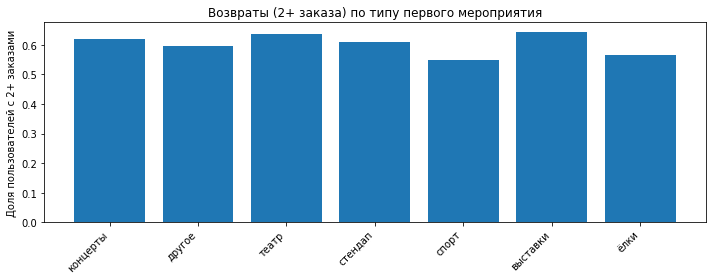

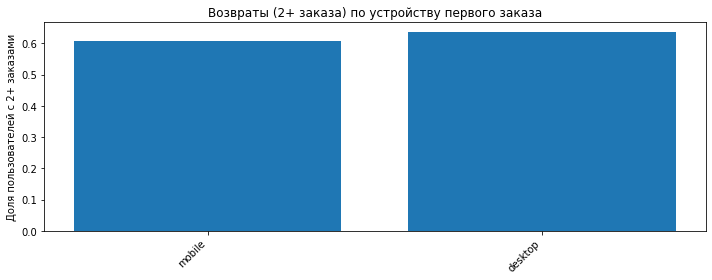

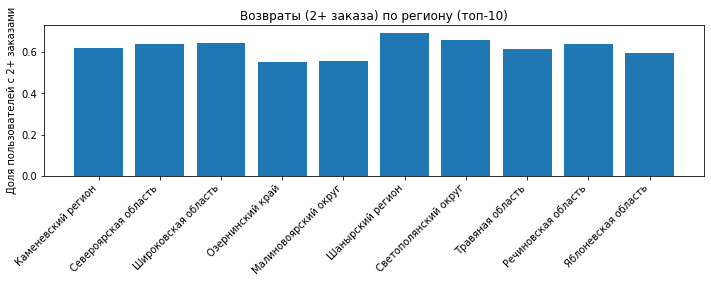

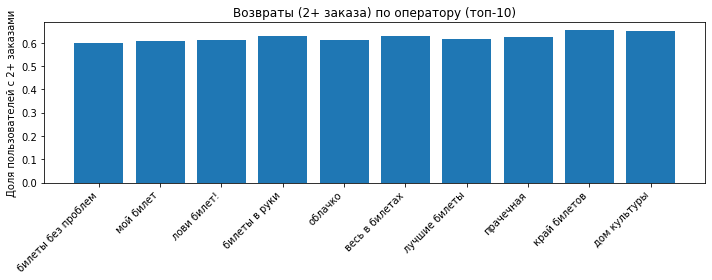

In [ ]:
import matplotlib.pyplot as plt

def plot_return_rate(seg_df, col, title):
    plt.figure(figsize=(10, 4))
    plt.bar(seg_df[col].astype(str), seg_df['return_rate'])
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Доля пользователей с 2+ заказами')
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_return_rate(ret_event,   'first_event_type', 'Возвраты (2+ заказа) по типу первого мероприятия')
plot_return_rate(ret_device,  'first_device',     'Возвраты (2+ заказа) по устройству первого заказа')
plot_return_rate(ret_region,  'first_region',     'Возвраты (2+ заказа) по региону (топ-10)')
plot_return_rate(ret_service, 'first_service',    'Возвраты (2+ заказа) по оператору (топ-10)')

> Для каждого сегмента, определённого по признакам первого заказа, была рассчитана доля пользователей, совершивших два и более заказа (метрика возврата).

1. Возвраты по типу первого мероприятия

По сегментам первого мероприятия доля вернувшихся пользователей находится в диапазоне примерно от 55% до 64%:

Наиболее высокие значения возвратов наблюдаются у сегментов:

выставки (~64.3%)

театр (~63.5%)

концерты (~61.8%)

стендап (~60.9%)

Более низкие значения:

другое (~59.4%)

ёлки (~56.7%)

спорт (~54.9%)

При этом важно учитывать размер сегментов:

Самые массовые сегменты — концерты, другое и театр — показывают стабильно высокий уровень возвратов (около 60% и выше).

Сегменты с малым числом пользователей (например, ёлки, выставки) могут демонстрировать более волатильные значения, поэтому их стоит интерпретировать с осторожностью.

2. Есть ли «успешные точки входа»?

Можно говорить о наличии относительно успешных точек входа:

Первый заказ на выставки и театр ассоциирован с более высокой вероятностью повторной покупки.

Концерты — самый массовый сегмент — при этом тоже показывают возврат выше ~60%, что делает его ключевой и качественной точкой входа с точки зрения и объёма, и удержания.

3. Общий вывод

Возврат пользователей сильно зависит от типа первого мероприятия, но различия находятся в пределах ~10 п.п.

В целом, большинство крупных сегментов демонстрируют высокую вероятность повторной покупки (≈60% и выше).

Наиболее перспективными «точками входа» выглядят:

концерты — за счёт масштаба и хорошего retention,

театр и выставки — за счёт более высокой доли возвращающихся пользователей.

Эти сегменты стоит рассматривать как приоритетные при анализе и развитии воронки привлечения и удержания пользователей.

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

In [ ]:
# Гипотеза 1: спорт vs концерты
# Проверяем: отличается ли доля пользователей с 2+ заказами (is_two) для "спорт" и "концерты"

def normalize_text(s):
    return str(s).strip().lower()

# 1) Нормализуем тип первого события
user_profile_filtered["first_event_type_norm"] = (
    user_profile_filtered["first_event_type"].map(normalize_text)
)

# 2) Маски для спорта и концертов
sport_mask = user_profile_filtered["first_event_type_norm"].str.contains("спорт", na=False)
concert_mask = user_profile_filtered["first_event_type_norm"].str.contains("концерт", na=False)

# 3) Считаем долю пользователей с 2+ заказами
sport_rate = user_profile_filtered.loc[sport_mask, "is_two"].mean()
concert_rate = user_profile_filtered.loc[concert_mask, "is_two"].mean()

# 4) (опционально) размеры сегментов, чтобы понимать надежность сравнения
sport_users = user_profile_filtered.loc[sport_mask, "user_id"].nunique()
concert_users = user_profile_filtered.loc[concert_mask, "user_id"].nunique()

# 5) Выводим результат
print(f"Sport:   users={sport_users},  return_rate(2+ orders)={sport_rate:.4f}")
print(f"Concert: users={concert_users}, return_rate(2+ orders)={concert_rate:.4f}")

# Если хочешь — можно еще разницу вывести
print(f"Difference (sport - concert) = {(sport_rate - concert_rate):.4f}")


Sport:   users=765,  return_rate(2+ orders)=0.5490
Concert: users=9607, return_rate(2+ orders)=0.6178
Difference (sport - concert) = -0.0688


> Гипотеза 1: «Пользователи, пришедшие через спорт, возвращаются чаще, чем через концерты»

Мы сравнили долю пользователей с **2+ заказами (is_two)** для сегментов:
- **Спорт**
- **Концерты**

Полученные результаты:
- **Спорт:** 765 пользователей, доля возвратов = **0.549** (~54.9%)
- **Концерты:** 9607 пользователей, доля возвратов = **0.618** (~61.8%)
- Разница (спорт − концерты) = **−0.069** (−6.9 п.п.)

> Вывод
Гипотеза **не подтверждается**: пользователи, совершившие первый заказ на **концерты**, возвращаются **чаще**, чем пользователи, пришедшие через **спорт**.

>> Комментарий по надёжности сравнения
Сегмент «спорт» заметно меньше по размеру (765 пользователей против 9607 у «концертов»), поэтому его оценка может быть менее стабильной. Тем не менее, даже с учётом этого ограничения, разница в долях возврата наблюдается **в пользу концертов**, а не спорта.


In [ ]:
# считаем по регионам: размер сегмента и return_rate
region_stats = (
    user_profile_filtered
    .groupby("first_region")
    .agg(
        users_cnt=("user_id", "nunique"),
        return_rate=("is_two", "mean")
    )
    .reset_index()
)

# считаем корреляцию Спирмена
corr, pval = spearmanr(region_stats["users_cnt"], region_stats["return_rate"])

print(f"Spearman correlation = {corr:.3f}")
print(f"p-value = {pval:.4f}")


Spearman correlation = 0.306
p-value = 0.0054


> Проверка гипотезы 2: связь размера региона и доли повторных заказов

**Гипотеза:**  
В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

Для проверки гипотезы для каждого региона были рассчитаны:
- размер сегмента (количество уникальных пользователей),
- доля пользователей с 2+ заказами (`return_rate`).

Затем была посчитана корреляция Спирмена между размером региона и долей повторных заказов.

**Результаты:**
- Коэффициент корреляции Спирмена: **0.306**
- p-value: **0.0054**

**Интерпретация:**
- Наблюдается **умеренная положительная связь** между размером региона и долей повторных заказов.
- Значение p-value < 0.05 говорит о том, что связь **статистически значима** и с высокой вероятностью не является случайной.
- Это означает, что в более «крупных» и активных регионах действительно **в среднем выше доля пользователей, совершающих повторные заказы**.

**Вывод:**
Гипотеза 2 **подтверждается данными**: чем больше пользователей в регионе, тем, как правило, выше доля повторных заказов. При этом связь не очень сильная, поэтому размер региона — важный, но не единственный фактор, влияющий на возвраты.


---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


In [ ]:
# две группы пользователей
one_order = user_profile_filtered[user_profile_filtered["is_two"] == 0]
repeat_orders = user_profile_filtered[user_profile_filtered["is_two"] == 1]

one_order.shape, repeat_orders.shape

((8318, 14), (13165, 14))

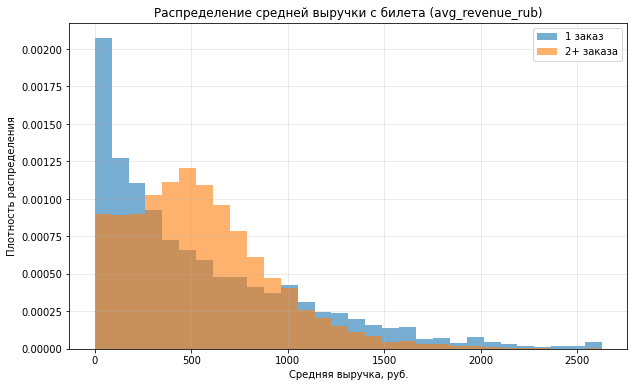

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

bins = 30

plt.hist(
    one_order["avg_revenue_rub"].dropna(),
    bins=bins,
    density=True,
    alpha=0.6,
    label="1 заказ"
)

plt.hist(
    repeat_orders["avg_revenue_rub"].dropna(),
    bins=bins,
    density=True,
    alpha=0.6,
    label="2+ заказа"
)

plt.title("Распределение средней выручки с билета (avg_revenue_rub)")
plt.xlabel("Средняя выручка, руб.")
plt.ylabel("Плотность распределения")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [ ]:
one_stats = one_order["avg_revenue_rub"].describe()
repeat_stats = repeat_orders["avg_revenue_rub"].describe()

one_stats, repeat_stats

(count    8318.000000
 mean      552.678607
 std       519.044834
 min         0.070000
 25%       141.140000
 50%       388.715000
 75%       839.520000
 max      2628.421739
 Name: avg_revenue_rub, dtype: float64,
 count    13165.000000
 mean       551.803407
 std        369.112033
 min          0.352000
 25%        278.415000
 50%        503.268000
 75%        751.592298
 max       2628.421739
 Name: avg_revenue_rub, dtype: float64)

> Связь средней выручки с билета и повторных заказов

Мы сравнили распределения средней выручки с билета (`avg_revenue_rub`) для двух групп пользователей:
- пользователей, совершивших только один заказ;
- пользователей, совершивших 2 и более заказов (вернувшихся пользователей).

Для сравнения были построены гистограммы с одинаковыми параметрами (`bins`, `alpha`, `density=True`), что позволяет корректно сопоставить форму распределений.

**Наблюдения по распределениям:**
- В обеих группах распределения имеют правостороннюю асимметрию с длинным «хвостом» дорогих покупок.
- Основная масса пользователей с одним заказом сосредоточена в более низких значениях средней выручки.
- У вернувшихся пользователей распределение смещено вправо: чаще встречаются более высокие значения средней выручки.

**Числовое сравнение:**
- Для пользователей с одним заказом:
  - медиана ≈ 389 руб.,
  - среднее ≈ 553 руб.
- Для пользователей с 2+ заказами:
  - медиана ≈ 503 руб.,
  - среднее ≈ 552 руб.

При этом медиана у вернувшихся пользователей заметно выше, чем у пользователей с одним заказом, что говорит о смещении распределения в сторону более дорогих покупок. Средние значения при этом почти одинаковы из-за влияния длинного правого «хвоста» у обеих групп.

**Вывод:**
Пользователи, которые совершают повторные заказы, в среднем покупают билеты с более высокой типичной (медианной) выручкой. Это указывает на связь между более высоким средним чеком и вероятностью возврата: пользователи с более дорогими покупками чаще возвращаются в сервис, хотя распределения двух групп частично пересекаются и эффект нельзя считать резким.


---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


In [ ]:
# Разобьём пользователей на группы
group_2_4 = user_profile_filtered.query("orders_cnt >= 2 and orders_cnt <= 4")
group_5_plus = user_profile_filtered.query("orders_cnt >= 5")

# Посмотрим размеры групп
print("2–4 orders:", group_2_4.shape[0])
print("5+ orders:", group_5_plus.shape[0])

2–4 orders: 7120
5+ orders: 6045


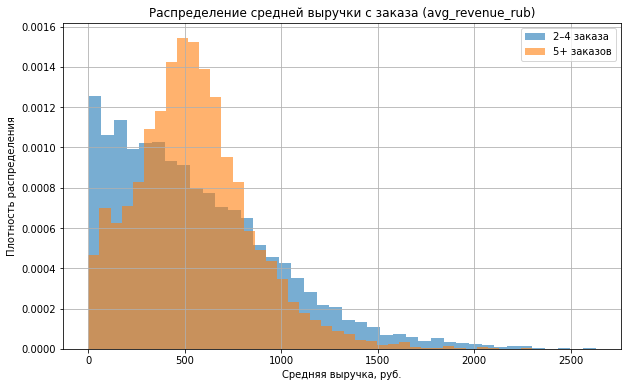

In [ ]:
# построми гистограмму 
plt.figure(figsize=(10, 6))

plt.hist(group_2_4["avg_revenue_rub"], bins=40, alpha=0.6, density=True, label="2–4 заказа")
plt.hist(group_5_plus["avg_revenue_rub"], bins=40, alpha=0.6, density=True, label="5+ заказов")

plt.title("Распределение средней выручки с заказа (avg_revenue_rub)")
plt.xlabel("Средняя выручка, руб.")
plt.ylabel("Плотность распределения")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Посмотрим описательные статистики
stats_2_4 = group_2_4["avg_revenue_rub"].describe()
stats_5_plus = group_5_plus["avg_revenue_rub"].describe()

stats_2_4, stats_5_plus

(count    7120.000000
 mean      557.610493
 std       420.035554
 min         2.416667
 25%       224.130417
 50%       477.645427
 75%       806.265625
 max      2628.421739
 Name: avg_revenue_rub, dtype: float64,
 count    6045.000000
 mean      544.963629
 std       298.070358
 min         0.352000
 25%       341.573611
 50%       521.755000
 75%       710.633636
 max      2299.869022
 Name: avg_revenue_rub, dtype: float64)

> Сравнение средней выручки с заказа для пользователей с 2–4 и 5+ заказами

Пользователи были разделены на две группы:
- пользователи, совершившие **2–4 заказа** (n = 7120);
- пользователи, совершившие **5 и более заказов** (n = 6045).

Для обеих групп были построены гистограммы распределения средней выручки с заказа (`avg_revenue_rub`) с одинаковыми параметрами визуализации, что позволило корректно сравнить форму распределений.

**Описательные статистики:**

- **Группа 2–4 заказа:**
  - среднее: **557.6 руб.**
  - медиана: **477.6 руб.**
  - 25-й перцентиль: **224.1 руб.**
  - 75-й перцентиль: **806.3 руб.**
  - максимум: **2628.4 руб.**

- **Группа 5+ заказов:**
  - среднее: **545.0 руб.**
  - медиана: **521.8 руб.**
  - 25-й перцентиль: **341.6 руб.**
  - 75-й перцентиль: **710.6 руб.**
  - максимум: **2299.9 руб.**

**Наблюдения по распределениям:**
- В обеих группах распределения имеют выраженную правостороннюю асимметрию (длинный хвост дорогих заказов).
- Медиана и нижний квартиль у группы **5+ заказов выше**, чем у группы 2–4 заказов, что говорит о более высокой «типичной» выручке с заказа у более лояльных пользователей.
- При этом среднее значение в группе 2–4 заказов немного выше, что объясняется более тяжёлым правым хвостом (наличием отдельных очень дорогих заказов).
- В целом распределения похожи по форме, но смещены: у пользователей с 5+ заказами значения более сконцентрированы в среднем диапазоне и менее вариативны.

**Вывод:**
Существенных радикальных различий между группами по форме распределений нет, однако пользователи с 5 и более заказами демонстрируют более высокие типичные значения средней выручки (по медиане и квартилям), что может указывать на более стабильное и «качественное» потребление сервиса по мере роста лояльности.


---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

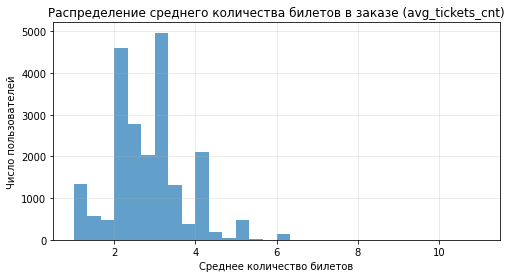

In [ ]:
# Посмотрим распределение avg_tickets_cnt
plt.figure(figsize=(8, 4))
plt.hist(user_profile_filtered["avg_tickets_cnt"], bins=30, alpha=0.7)
plt.title("Распределение среднего количества билетов в заказе (avg_tickets_cnt)")
plt.xlabel("Среднее количество билетов")
plt.ylabel("Число пользователей")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Создаём сегменты
bins = [1, 2, 3, 5, np.inf]
labels = ["1–2 билета", "2–3 билета", "3–5 билетов", "5+ билетов"]

user_profile_filtered["tickets_segment"] = pd.cut(
    user_profile_filtered["avg_tickets_cnt"],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

user_profile_filtered["tickets_segment"].value_counts()

2–3 билета     9831
1–2 билета     6109
3–5 билетов    5349
5+ билетов      194
Name: tickets_segment, dtype: int64

In [ ]:
tickets_seg_stats = (
    user_profile_filtered
    .groupby("tickets_segment")
    .agg(
        users_cnt=("user_id", "nunique"),
        return_rate=("is_two", "mean")
    )
    .reset_index()
)

tickets_seg_stats

,tickets_segment,users_cnt,return_rate
0,1–2 билета,6109,0.400229
1,2–3 билета,9831,0.742142
2,3–5 билетов,5349,0.628342
3,5+ билетов,194,0.324742


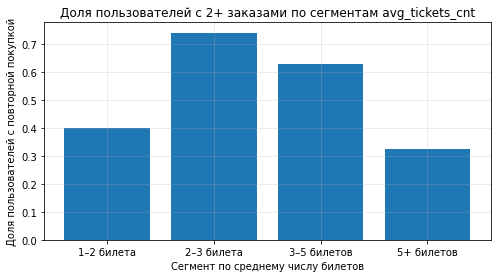

In [ ]:
plt.figure(figsize=(8, 4))
plt.bar(tickets_seg_stats["tickets_segment"], tickets_seg_stats["return_rate"])
plt.title("Доля пользователей с 2+ заказами по сегментам avg_tickets_cnt")
plt.xlabel("Сегмент по среднему числу билетов")
plt.ylabel("Доля пользователей с повторной покупкой")
plt.grid(True, alpha=0.3)
plt.show()

> Вывод



Сначала было изучено распределение среднего количества билетов в заказе (`avg_tickets_cnt`). Большинство пользователей сосредоточено в диапазоне от 1 до 3 билетов, при этом сегменты с 5 и более билетами являются малочисленными, что указывает на наличие длинного «хвоста» распределения.

Пользователи были разделены на сегменты по среднему числу билетов в заказе:
- 1–2 билета — 6109 пользователей;
- 2–3 билета — 9831 пользователь;
- 3–5 билетов — 5349 пользователей;
- 5+ билетов — 194 пользователя.

Для каждого сегмента была рассчитана доля пользователей, совершивших повторную покупку (2 и более заказов):

- **1–2 билета**: доля повторных покупок ≈ **40.0%**
- **2–3 билета**: доля повторных покупок ≈ **74.2%**
- **3–5 билетов**: доля повторных покупок ≈ **62.8%**
- **5+ билетов**: доля повторных покупок ≈ **32.5%**

#### Выводы

- Распределение пользователей по сегментам неравномерное: основная масса пользователей сосредоточена в сегментах **1–2** и **2–3 билета**.
- Наиболее высокая доля повторных покупок наблюдается в сегменте **2–3 билета**, а также высокая — в сегменте **3–5 билетов**.
- Сегмент **5+ билетов** является очень малочисленным, и несмотря на более низкую долю повторных покупок, его показатели могут быть нестабильны из-за малого размера выборки.
- В целом, пользователи, покупающие в среднем **2–5 билетов за заказ**, демонстрируют более высокую вероятность повторной покупки по сравнению с пользователями, покупающими в среднем **1–2 билета**.

Это позволяет сделать вывод, что среднее количество билетов в заказе связано с вероятностью повторной покупки, однако для крайних сегментов (особенно 5+) результаты следует интерпретировать с осторожностью из-за малого числа наблюдений.



---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [ ]:
# Убедимся, что дата в формате datetime
user_profile_filtered["first_order_dt"] = pd.to_datetime(user_profile_filtered["first_order_dt"])

# День недели: 0 = понедельник, 6 = воскресенье
user_profile_filtered["first_order_weekday"] = user_profile_filtered["first_order_dt"].dt.dayofweek

# Для наглядности добавим названия дней
weekday_map = {
    0: "Пн", 1: "Вт", 2: "Ср", 3: "Чт", 4: "Пт", 5: "Сб", 6: "Вс"
}
user_profile_filtered["first_order_weekday_name"] = user_profile_filtered["first_order_weekday"].map(weekday_map)

In [ ]:
weekday_stats = (
    user_profile_filtered
    .groupby("first_order_weekday_name")
    .agg(
        users_cnt=("user_id", "nunique"),
        return_rate=("is_two", "mean")
    )
    .reset_index()
)

# Отсортируем по порядку дней недели
order = ["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]
weekday_stats["first_order_weekday_name"] = pd.Categorical(
    weekday_stats["first_order_weekday_name"], categories=order, ordered=True
)
weekday_stats = weekday_stats.sort_values("first_order_weekday_name")

weekday_stats

,first_order_weekday_name,users_cnt,return_rate
2,Пн,2901,0.626336
1,Вт,3157,0.617358
5,Ср,3048,0.621719
6,Чт,3098,0.594900
3,Пт,3230,0.599071
4,Сб,3292,0.627886
0,Вс,2757,0.601741


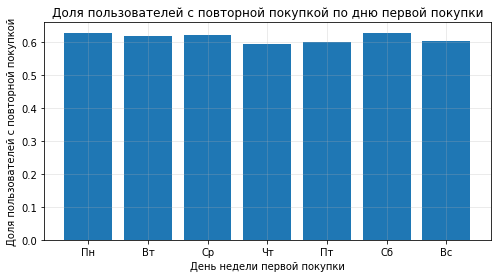

In [ ]:
plt.figure(figsize=(8, 4))
plt.bar(weekday_stats["first_order_weekday_name"], weekday_stats["return_rate"])
plt.title("Доля пользователей с повторной покупкой по дню первой покупки")
plt.xlabel("День недели первой покупки")
plt.ylabel("Доля пользователей с повторной покупкой")
plt.grid(True, alpha=0.3)
plt.show()



Для каждого пользователя был определён день недели, в который была совершена первая покупка. Далее для каждого дня недели были рассчитаны:
- количество пользователей;
- доля пользователей, совершивших повторную покупку (2 и более заказов).

Результаты показали, что доля повторных покупок по дням недели находится в узком диапазоне — примерно от **0.59 до 0.63**.  
Минимальное значение наблюдается для пользователей, совершивших первую покупку в **четверг (~0.595)**, максимальное — в **субботу (~0.628)**. Для остальных дней недели значения находятся очень близко друг к другу (около 0.60–0.62).

Таким образом, **день недели первой покупки не оказывает существенного влияния на вероятность возврата пользователя**. Небольшие различия между днями присутствуют, но они не носят выраженного характера и, скорее всего, не являются продуктово значимыми.


---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [ ]:
# Разделим пользователей на группы:
# 2–4 заказа и 5+ заказов

group_2_4 = user_profile_filtered[
    (user_profile_filtered["orders_cnt"] >= 2) & (user_profile_filtered["orders_cnt"] <= 4)
]

group_5_plus = user_profile_filtered[
    user_profile_filtered["orders_cnt"] >= 5
]

# Посмотрим описательные статистики по среднему интервалу между заказами
stats_2_4 = group_2_4["avg_days_between_orders"].describe()
stats_5_plus = group_5_plus["avg_days_between_orders"].describe()

stats_2_4, stats_5_plus

(count    7120.000000
 mean       21.233052
 std        28.366050
 min         0.000000
 25%         0.000000
 50%         9.000000
 75%        33.500000
 max       148.000000
 Name: avg_days_between_orders, dtype: float64,
 count    6045.000000
 mean        9.893359
 std         7.795154
 min         0.000000
 25%         3.882353
 50%         8.111111
 75%        14.125000
 max        37.500000
 Name: avg_days_between_orders, dtype: float64)

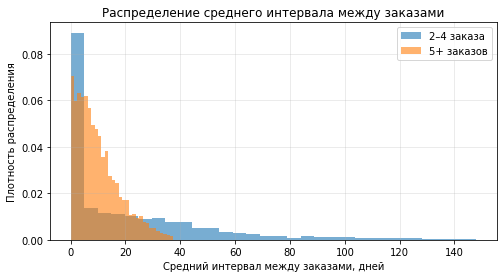

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(group_2_4["avg_days_between_orders"], bins=30, alpha=0.6, label="2–4 заказа", density=True)
plt.hist(group_5_plus["avg_days_between_orders"], bins=30, alpha=0.6, label="5+ заказов", density=True)

plt.title("Распределение среднего интервала между заказами")
plt.xlabel("Средний интервал между заказами, дней")
plt.ylabel("Плотность распределения")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Пользователи были разделены на две группы:
- совершившие **2–4 заказа**;
- совершившие **5 и более заказов**.

Для сравнения был использован показатель `avg_days_between_orders` — средний интервал между заказами.

**Результаты:**

- Для пользователей с **2–4 заказами**:
  - средний интервал: **21.23 дня**,
  - медиана: **9.0 дней**,
  - 75-й перцентиль: **33.5 дня**,
  - наблюдается длинный «хвост» распределения (до ~148 дней).

- Для пользователей с **5 и более заказами**:
  - средний интервал: **9.89 дня**,
  - медиана: **8.11 дня**,
  - 75-й перцентиль: **14.25 дня**,
  - распределение более компактное и смещено к меньшим значениям.

Визуально и по статистикам видно, что пользователи с большим числом заказов совершают покупки **значительно чаще** и с **меньшими паузами** между ними.

**Вывод:**  
Чем **меньше средний интервал между заказами**, тем выше вероятность того, что пользователь станет более лояльным и совершит **5 и более покупок**. Показатель частоты покупок является важным фактором удержания: активные пользователи возвращаются быстрее и стабильнее, чем пользователи с редкими покупками.


---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [ ]:
# соьираем датасет для корреляции
cols_for_corr = [
    "orders_cnt",               # целевая
    "avg_revenue_rub",
    "avg_tickets_cnt",
    "avg_days_between_orders",
    "first_device",
    "first_region",
    "first_service",
    "first_event_type",
    "first_order_weekday_name"
]

corr_df = user_profile_filtered[cols_for_corr].copy()
corr_df.head()

,orders_cnt,avg_revenue_rub,avg_tickets_cnt,avg_days_between_orders,first_device,first_region,first_service,first_event_type,first_order_weekday_name
0,1,1521.940000,4.000000,NaN,mobile,Каменевский регион,край билетов,театр,Вт
1,2,774.010000,3.000000,75.0,mobile,Каменевский регион,мой билет,выставки,Вт
2,3,767.213333,2.666667,51.0,mobile,Североярская область,лови билет!,другое,Сб
3,1,917.830000,4.000000,NaN,desktop,Каменевский регион,край билетов,театр,Чт
4,2,61.310000,1.500000,16.0,mobile,Поленовский край,лучшие билеты,театр,Вс


In [ ]:
interval_cols = [
    "orders_cnt",
    "avg_revenue_rub",
    "avg_tickets_cnt",
    "avg_days_between_orders"
]

phi_k_corr = corr_df.phik_matrix(interval_cols=interval_cols)
phi_k_corr

,orders_cnt,avg_revenue_rub,avg_tickets_cnt,avg_days_between_orders,first_device,first_region,first_service,first_event_type,first_order_weekday_name
orders_cnt,1.000000,0.225679,0.230620,0.295374,0.015763,0.124086,0.031170,0.028032,0.053450
avg_revenue_rub,0.225679,1.000000,0.459334,0.089138,0.077537,0.364385,0.376585,0.324867,0.010097
avg_tickets_cnt,0.230620,0.459334,1.000000,0.102409,0.056192,0.160615,0.067872,0.098825,0.004081
avg_days_between_orders,0.295374,0.089138,0.102409,1.000000,0.021784,0.077643,0.053993,0.048050,0.000000
first_device,0.015763,0.077537,0.056192,0.021784,1.000000,0.114455,0.083754,0.062017,0.071906
first_region,0.124086,0.364385,0.160615,0.077643,0.114455,1.000000,0.698395,0.512897,0.159725
first_service,0.031170,0.376585,0.067872,0.053993,0.083754,0.698395,1.000000,0.586470,0.059811
first_event_type,0.028032,0.324867,0.098825,0.048050,0.062017,0.512897,0.586470,1.000000,0.082350
first_order_weekday_name,0.053450,0.010097,0.004081,0.000000,0.071906,0.159725,0.059811,0.082350,1.000000


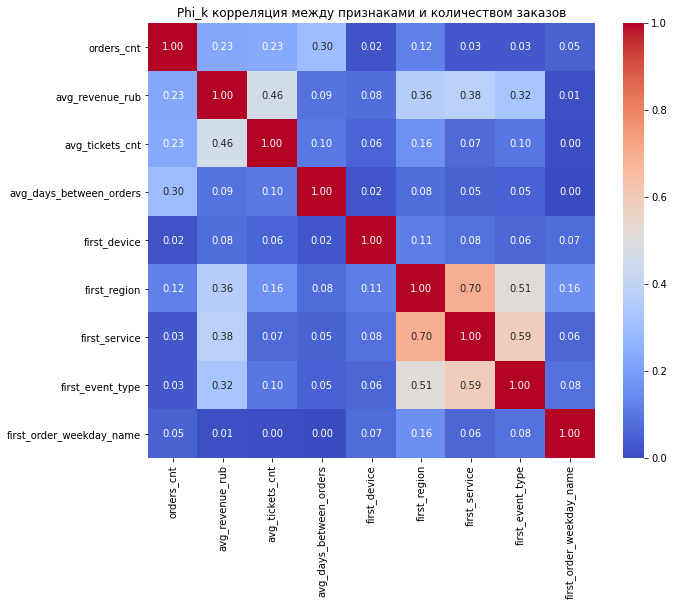

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(phi_k_corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Phi_k корреляция между признаками и количеством заказов")
plt.show()

Для анализа связи между характеристиками профиля пользователя и количеством заказов был использован коэффициент корреляции phi_k, который позволяет учитывать как числовые, так и категориальные признаки. Результаты представлены в виде тепловой карты корреляций.

Основные наблюдения

Наибольшую связь с количеством заказов `(orders_cnt)` показывают:

`avg_days_between_orders (φ ≈ 0.30)` — средний интервал между заказами;

`avg_tickets_cnt (φ ≈ 0.23)` — среднее количество билетов в заказе;

`avg_revenue_rub (φ ≈ 0.23)` — средняя выручка с заказа.

Категориальные признаки:

`first_device, first_service, first_event_type, first_order_weekday_name` имеют очень слабую корреляцию с числом заказов `(φ ≈ 0.02–0.05)`, то есть практически не влияют на количество покупок.

`first_region` демонстрирует слабую связь с `orders_cnt (φ ≈ 0.12)`.

Между некоторыми категориальными признаками (например, `first_region, first_service, first_event_type`) наблюдается высокая взаимная корреляция, что может отражать особенности регионов и ассортимента, но напрямую не определяет количество заказов пользователя.

Вывод

Количество заказов пользователя в большей степени связано с поведенческими и количественными характеристиками — частотой покупок, средним числом билетов и средним чеком.
Контекст первого заказа (устройство, сервис, тип события, день недели) не является определяющим фактором для числа покупок и оказывает лишь слабое влияние.

Основные драйверы роста числа заказов — это интенсивность и масштаб потребления, а не параметры первого взаимодействия с сервисом.

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

# Итоговые выводы по проекту

 1. Подготовка данных и формирование профиля пользователя

В рамках проекта данные о заказах были объединены в единый датасет и агрегированы на уровне пользователя.  
В процессе подготовки данных:

- оставлены только основные типы устройств (mobile и desktop);
- выручка приведена к единой валюте (рубли) с учётом курса тенге;
- проверены пропуски и аномалии (пропуски ожидаемы у пользователей с одной покупкой);
- выполнена оптимизация типов данных;
- обработаны выбросы в показателях выручки;
- рассчитаны пользовательские метрики:
  - число заказов (`orders_cnt`),
  - средняя выручка с заказа (`avg_revenue_rub`),
  - среднее число билетов (`avg_tickets_cnt`),
  - средний интервал между заказами (`avg_days_between_orders`),
  - признаки первого заказа (устройство, регион, сервис, тип события, день недели).

Это позволило перейти от сырых логов заказов к профилю пользователя, удобному для анализа поведения.

---

 2. Общая характеристика пользователей

- В выборке представлено более 20 тысяч пользователей.
- Большинство пользователей совершают 1–2 заказа, однако значимая доля возвращается и делает повторные покупки.
- Также выделяется сегмент пользователей с 5 и более заказами, что указывает на наличие лояльной аудитории.

---

 3. Выручка и размер заказа

- Пользователи с повторными заказами имеют более высокую медианную выручку с заказа по сравнению с пользователями с одним заказом.
- Средние значения выручки между группами отличаются слабее из-за влияния выбросов.
- Анализ среднего количества билетов в заказе показал:
  - максимальная доля повторных покупок у пользователей с **2–3 билетами** в среднем;
  - сегмент **3–5 билетов** также демонстрирует высокую долю возвратов;
  - сегмент **5+ билетов** имеет заметно более низкую долю повторных покупок, что, вероятно, связано с разовыми групповыми покупками.

Таким образом, размер заказа влияет на вероятность возврата, но зависимость носит нелинейный характер.

---

 4. Временные характеристики поведения

- День недели первой покупки практически не влияет на вероятность возврата: различия между днями минимальны.
- Средний интервал между заказами является более важным фактором:
  - пользователи с **5 и более заказами** совершают покупки заметно чаще;
  - пользователи с **2–4 заказами** имеют более длинные паузы между покупками.

Это подтверждает, что частота покупок является ключевой характеристикой лояльности.

---

5. Корреляционный анализ (phi_k)

Для анализа связей между признаками и количеством заказов использовался коэффициент `phi_k`.

Основные результаты:

- Связь количества заказов (`orders_cnt`) с отдельными признаками в целом слабая:
  - с `avg_revenue_rub` и `avg_tickets_cnt` — слабая положительная корреляция;
  - с `avg_days_between_orders` — наиболее заметная, но всё ещё умеренная связь;
  - с признаками первого заказа (устройство, регион, сервис, тип события, день недели) — очень слабая связь или её отсутствие.
- Между некоторыми категориальными признаками (регион, сервис, тип события) наблюдаются сильные взаимные корреляции, что отражает структуру данных, но не указывает на прямое влияние на количество заказов.

В целом анализ показывает, что глубина лояльности лучше объясняется поведенческими метриками, чем характеристиками первого заказа.

---

 6. Общий вывод

Удержание пользователей в большей степени определяется их поведением:

- частотой покупок,
- размером заказа,
- уровнем выручки.

Параметры первого заказа сами по себе не являются определяющими факторами лояльности. Первое взаимодействие важно для входа в сервис, но дальнейшая лояльность формируется за счёт устойчивых сценариев использования сервиса.

---

7. Рекомендации

- **Сфокусироваться на сегменте 2–3 билета в заказе** — это самый массовый и наиболее лояльный сегмент.
- **Работать с частотой покупок**: использовать напоминания, персональные рекомендации и подборки для сокращения интервалов между заказами.
- **Использовать сегментированный подход**:
  - для пользователей с 5+ заказами — программы лояльности и долгосрочные бонусы;
  - для пользователей с 1 заказом — отдельные коммуникации для стимулирования повторной покупки.
- **В аналитических и прогнозных моделях** делать упор на поведенческие признаки (интервалы между заказами, среднее число билетов, выручка), а признаки первого заказа использовать как вспомогательные.
